In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy

# Polar coordinates

In [2]:
def process_data(data_txt, data_col):
    # Read data
    cols = ['DATE', data_col, 'SIGMA']
    cols_widths = [(0,11),(12,22),(23,33)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [3]:
df_X = process_data('C04 20 x.txt', 'X')
df_X.head(5)

,DATE,X,SIGMA
0,2000.0000,43.261,0.084
1,2000.0027,43.502,0.080
2,2000.0055,43.604,0.078
3,2000.0082,43.417,0.077
4,2000.0110,43.105,0.076


In [4]:
df_Y = process_data('C04 20 y.txt', 'Y')
df_Y.head(5)

,DATE,Y,SIGMA
0,2000.0000,377.991,0.067
1,2000.0027,377.750,0.064
2,2000.0055,377.446,0.062
3,2000.0082,377.153,0.061
4,2000.0110,376.856,0.061


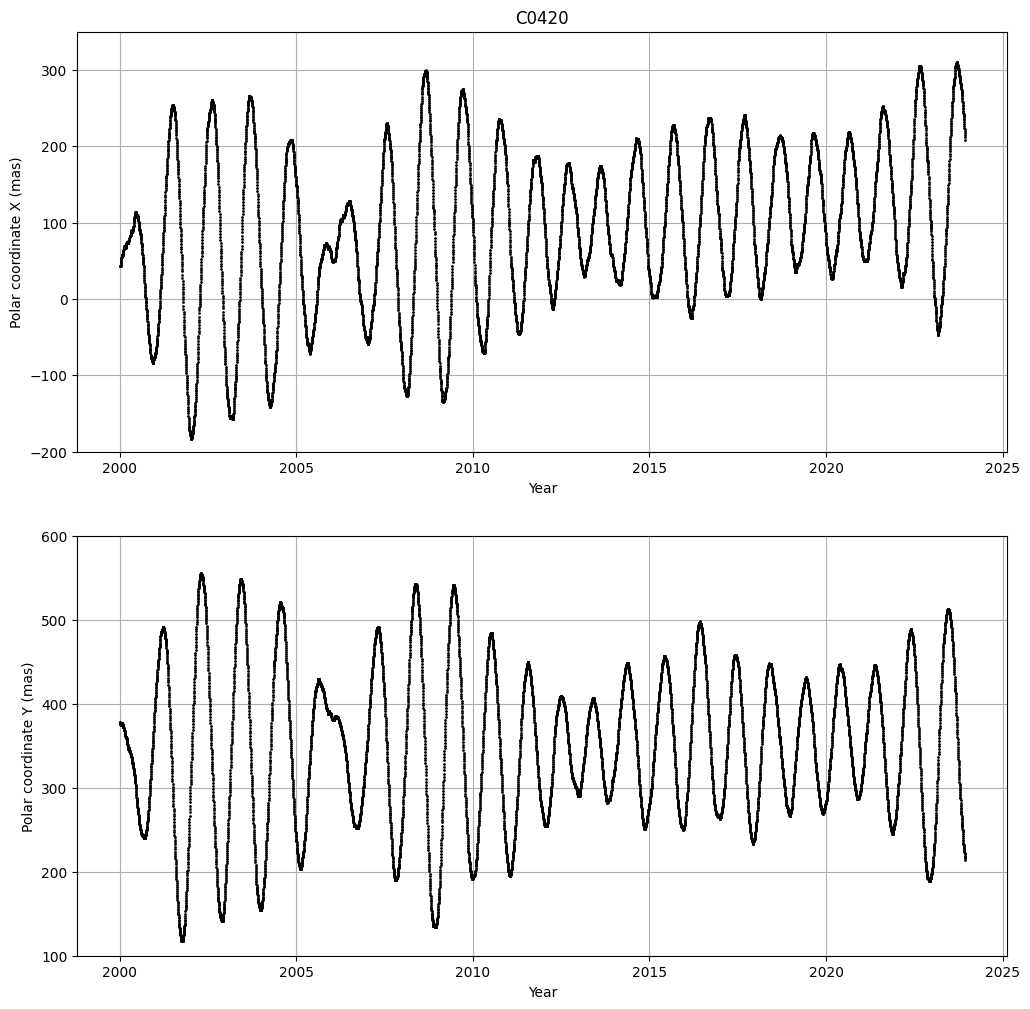

In [5]:
plt.figure(figsize=(12,12))
plt.subplot(211)
plt.title('C0420')
plt.errorbar(df_X['DATE'], df_X['X'],yerr=df_X['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-200,350)
plt.xlabel('Year')
plt.ylabel('Polar coordinate X (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_Y['DATE'], df_Y['Y'], yerr=df_Y['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(100,600)
plt.xlabel('Year')
plt.ylabel('Polar coordinate Y (mas)')
plt.grid()
plt.show()

In [6]:
df_X_sel = df_X.iloc[::2]
df_Y_sel = df_Y.iloc[::2]

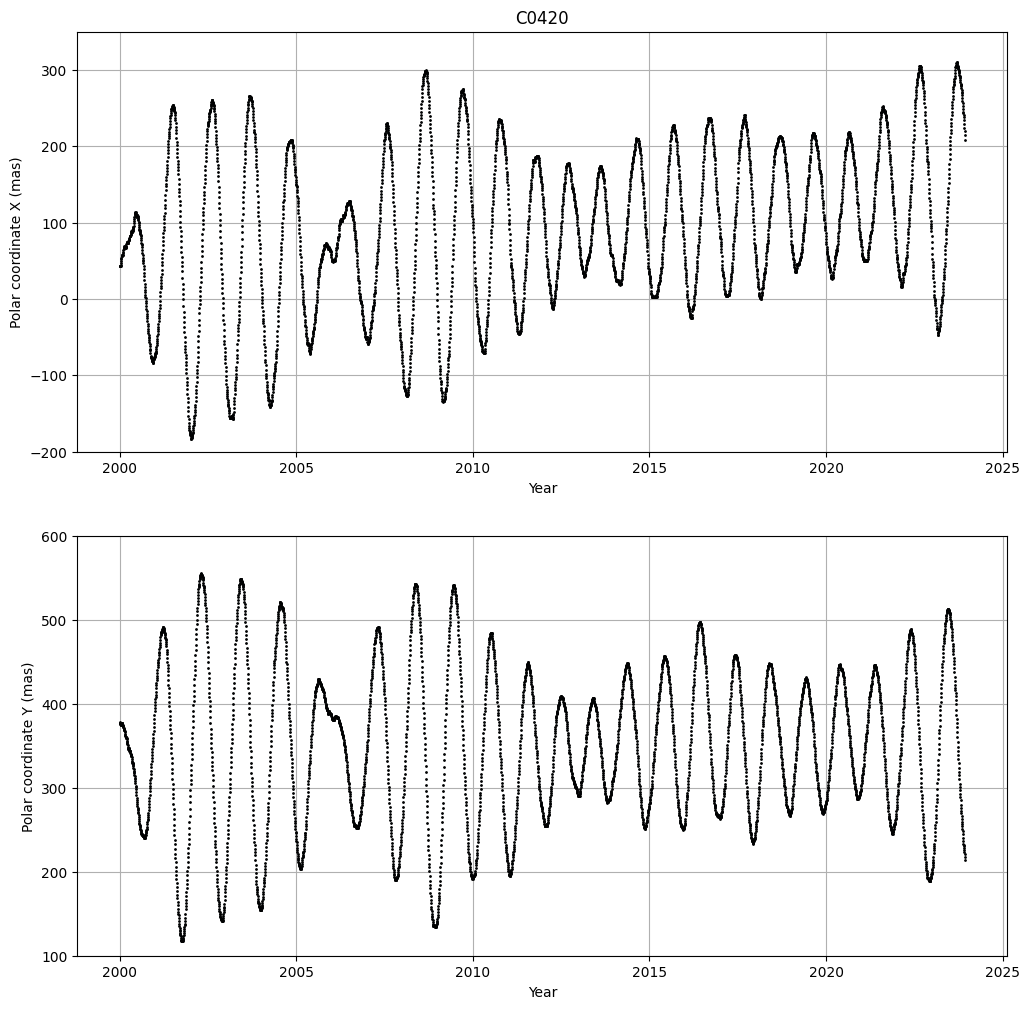

In [7]:
plt.figure(figsize=(12,12))
plt.subplot(211)
plt.title('C0420')
plt.errorbar(df_X_sel['DATE'], df_X_sel['X'],yerr=df_X_sel['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-200,350)
plt.xlabel('Year')
plt.ylabel('Polar coordinate X (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_Y_sel['DATE'], df_Y_sel['Y'], yerr=df_Y_sel['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(100,600)
plt.xlabel('Year')
plt.ylabel('Polar coordinate Y (mas)')
plt.grid()
plt.show()

In [36]:
tau_X, allanstd_X = allanself.oadev(df_X_sel['X'].values,df_X_sel['DATE'].values,df_X_sel['SIGMA'].values)

In [37]:
tau_Y, allanstd_Y = allanself.oadev(df_Y_sel['Y'].values,df_Y_sel['DATE'].values,df_Y_sel['SIGMA'].values)

In [39]:
# np.savetxt('allanstd_X.txt', allanstd_X)
# np.savetxt('tau_X.txt', tau_X)

# np.savetxt('allanstd_Y.txt', allanstd_Y)
# np.savetxt('tau_Y.txt', tau_Y)

In [8]:
tau_X = np.loadtxt('tau_X.txt')
allanstd_X = np.loadtxt('allanstd_X.txt')

tau_Y = np.loadtxt('tau_Y.txt')
allanstd_Y = np.loadtxt('allanstd_Y.txt')

In [9]:
ci_X_low, ci_X_high = allanself.confidence_int(df_X_sel['X'].values,df_X_sel['SIGMA'].values,allanstd_X,modified=False,overlapping=True,devtype='allan')
ci_Y_low, ci_Y_high = allanself.confidence_int(df_Y_sel['Y'].values,df_Y_sel['SIGMA'].values,allanstd_Y,modified=False,overlapping=True,devtype='allan')


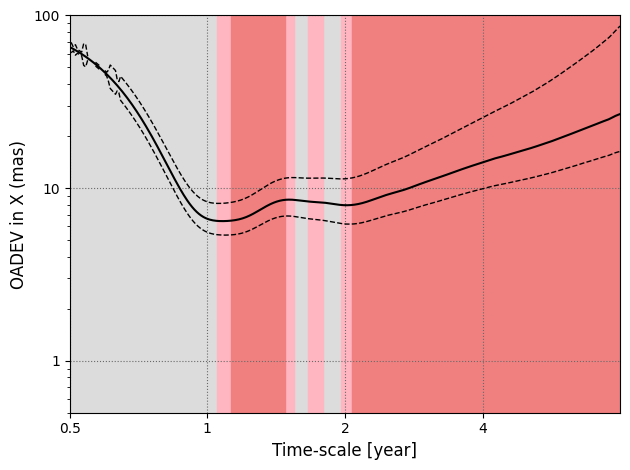

In [10]:
plt.figure()
# Calculate the slopes
slopes_X = np.diff(np.log10(allanstd_X)) / np.diff(np.log10(tau_X))
# Plot allanstd
plt.plot(tau_X,allanstd_X,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_X[1:], 0.1, 10**5, where= (slopes_X < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_X[1:], 0.1, 10**5, where= (-0.25 <= slopes_X) & (slopes_X <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_X[1:], 0.1, 10**5, where= (slopes_X > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_X, ci_X_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_X, ci_X_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in X (mas)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**2)
plt.xlim(0.5,max(tau_X))
plt.tight_layout()

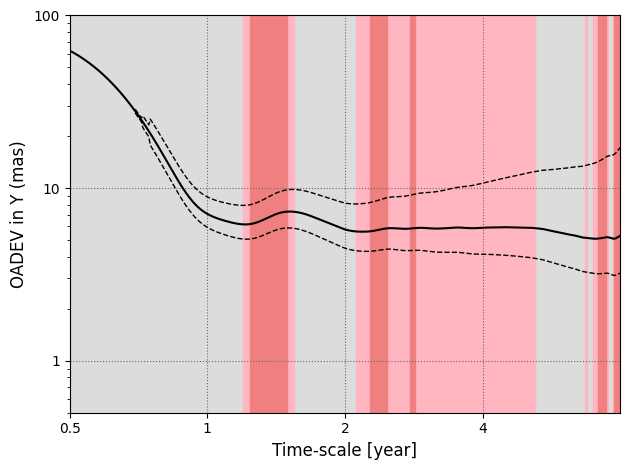

In [11]:
plt.figure()
# Calculate the slopes
slopes_Y = np.diff(np.log10(allanstd_Y)) / np.diff(np.log10(tau_Y))
# Plot allanstd
plt.plot(tau_Y,allanstd_Y,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (slopes_Y < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (-0.25 <= slopes_Y) & (slopes_Y <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (slopes_Y > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_Y, ci_Y_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_Y, ci_Y_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in Y (mas)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**2)
plt.xlim(0.5,max(tau_Y))
plt.tight_layout()

In [12]:
tau_X_had, hadstd_X = allanself.ohdev(df_X_sel['X'].values,df_X_sel['DATE'].values,df_X_sel['SIGMA'].values)


In [13]:
tau_Y_had, hadstd_Y = allanself.ohdev(df_Y_sel['Y'].values,df_Y_sel['DATE'].values,df_Y_sel['SIGMA'].values)


In [14]:
ci_X_had_low, ci_X_had_high = allanself.confidence_int(df_X_sel['X'].values,df_X_sel['SIGMA'].values,hadstd_X,modified=False,overlapping=True,devtype='hadamard')
ci_Y_had_low, ci_Y_had_high = allanself.confidence_int(df_Y_sel['Y'].values,df_Y_sel['SIGMA'].values,hadstd_Y,modified=False,overlapping=True,devtype='hadamard')


In [23]:
np.savetxt('hadstd_X.txt', hadstd_X)
np.savetxt('tau_X_had.txt', tau_X_had)

np.savetxt('hadstd_Y.txt', hadstd_Y)
np.savetxt('tau_Y_had.txt', tau_Y_had)

C:\Users\Davendra\AppData\Local\Temp\ipykernel_6536\1735953369.py:3: RuntimeWarning: divide by zero encountered in log10
  slopes_X_had = np.diff(np.log10(hadstd_X)) / np.diff(np.log10(tau_X_had))


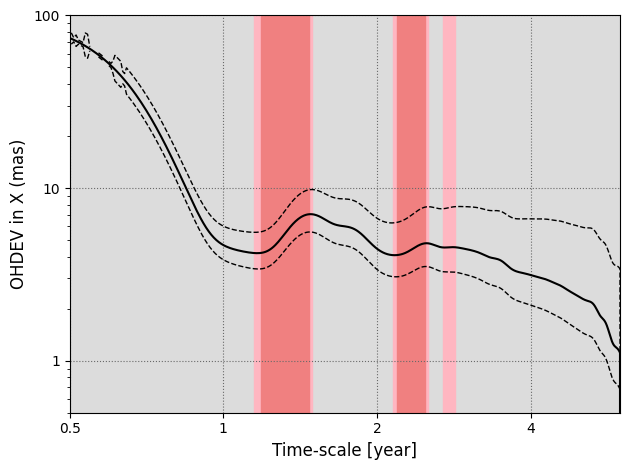

In [21]:
plt.figure()
# Calculate the slopes
slopes_X_had = np.diff(np.log10(hadstd_X)) / np.diff(np.log10(tau_X_had))
# Plot hadamard std
plt.plot(tau_X_had,hadstd_X,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_X_had[1:], 0.1, 10**5, (slopes_X_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_X_had[1:], 0.1, 10**5, (-0.25 <= slopes_X_had ) & (slopes_X_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_X_had[1:], 0.1, 10**5, (slopes_X_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_X_had, ci_X_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_X_had, ci_X_had_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OHDEV in X (mas)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,100)
plt.xlim(0.5,tau_X_had[np.count_nonzero(hadstd_X)-1])
plt.tight_layout()

C:\Users\Davendra\AppData\Local\Temp\ipykernel_6536\601535909.py:3: RuntimeWarning: divide by zero encountered in log10
  slopes_Y_had = np.diff(np.log10(hadstd_Y)) / np.diff(np.log10(tau_Y_had))
C:\Users\Davendra\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\function_base.py:1448: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])


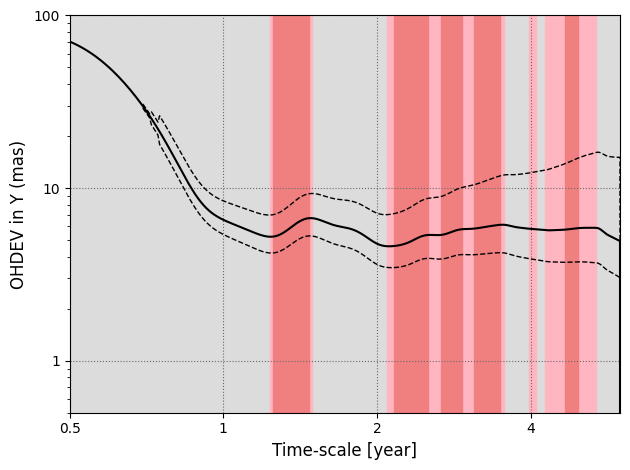

In [22]:
plt.figure()
# Calculate the slopes
slopes_Y_had = np.diff(np.log10(hadstd_Y)) / np.diff(np.log10(tau_Y_had))
# Plot hadamard std
plt.plot(tau_Y_had,hadstd_Y,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (slopes_Y_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (-0.25 <= slopes_Y_had ) & (slopes_Y_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (slopes_Y_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_Y_had, ci_Y_had_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_Y_had, ci_Y_had_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OHDEV in Y (mas)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,100)
plt.xlim(0.5,tau_Y_had[np.count_nonzero(hadstd_Y)-1])
plt.tight_layout()

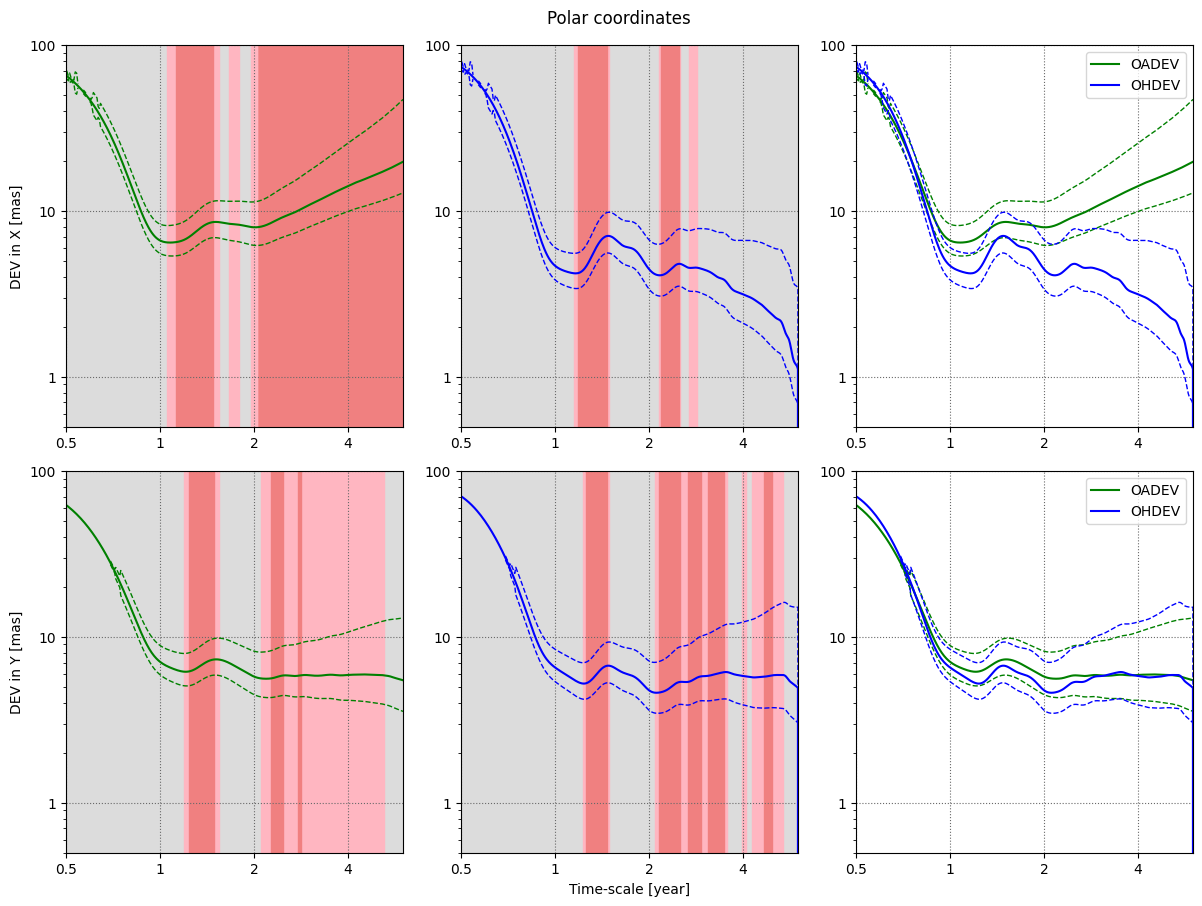

In [29]:
fig = plt.figure(figsize=(12,9))
fig.add_subplot(231)   
fig.add_subplot(232)  
fig.add_subplot(233)   
fig.add_subplot(234)  
fig.add_subplot(235) 
fig.add_subplot(236) 


fig.suptitle('Polar coordinates')

plt.tight_layout()

plt.subplot(231)
# Plot allanstd
plt.plot(tau_X,allanstd_X,color='green',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_X[1:], 0.1, 10**5, (slopes_X  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_X[1:], 0.1, 10**5, (-0.25 <= slopes_X) & (slopes_X <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_X[1:], 0.1, 10**5, (slopes_X  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_X, ci_X_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_X, ci_X_high,color='green',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'DEV in X [mas]')
plt.ylim(0.5,10**2)
plt.xlim(0.5,tau_X[np.count_nonzero(hadstd_X)-1])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

plt.subplot(232)
# Plot hadamard
plt.plot(tau_X_had,hadstd_X,color='blue',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_X_had[1:], 0.1, 10**5, where= (slopes_X_had  < -0.25), color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_X_had[1:], 0.1, 10**5, where= (-0.25 <= slopes_X_had ) & (slopes_X_had  <= 0.25),color='lightpink',linewidth=1.0,zorder=1)
plt.fill_between(tau_X_had[1:], 0.1, 10**5, where= (slopes_X_had  > 0.25),color='lightcoral',step='mid',linewidth=1.0,zorder=1)
# Plot confidence interval
plt.plot(tau_X_had, ci_X_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_X_had, ci_X_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylim(0.5,10**2)
plt.xlim(0.5,tau_X[np.count_nonzero(hadstd_X)-1])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))


plt.subplot(233)
plt.grid(color='dimgray',linestyle='dotted')
# Plot OADEV and CIs
plt.plot(tau_X,allanstd_X,color='green',label='OADEV')
plt.plot(tau_X, ci_X_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_X, ci_X_high,color='green',linestyle='dashed',linewidth=1)

# Plot OHDEV and CIs
plt.plot(tau_X_had,hadstd_X,color='blue',label='OHDEV')
plt.plot(tau_X_had, ci_X_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_X_had, ci_X_had_high,color='blue',linestyle='dashed',linewidth=1)

plt.xlim(0.5,tau_X_had[np.count_nonzero(hadstd_X)-1])
plt.ylim(0.5,10**2)
plt.xscale('log',base = 2)
plt.yscale('log')
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

plt.subplot(236)
plt.grid(color='dimgray',linestyle='dotted')
# Plot OADEV and CIs
plt.plot(tau_Y,allanstd_Y,color='green',label='OADEV')
plt.plot(tau_Y, ci_Y_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_Y, ci_Y_high,color='green',linestyle='dashed',linewidth=1)
# Plot OHDEV and CIs
plt.plot(tau_Y_had,hadstd_Y,color='blue',label='OHDEV')
plt.plot(tau_Y_had, ci_Y_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_Y_had, ci_Y_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.xlim(0.5,tau_Y_had[np.count_nonzero(hadstd_Y)-1])
plt.ylim(0.5,10**2)
plt.xscale('log',base = 2)
plt.yscale('log')
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))


plt.subplot(235)
# Plot hadamard std
plt.plot(tau_Y_had,hadstd_Y,color='blue',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (slopes_Y_had < 0.25),color='gainsboro',linewidth=1.0,zorder=1)
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (-0.25 <= slopes_Y_had ) & (slopes_Y_had  <= 0.25),color='lightpink',linewidth=1.0)
plt.fill_between(tau_Y_had[1:], 0.1, 10**5, (slopes_Y_had > 0.25),color='lightcoral',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_Y_had, ci_Y_had_low,color='blue',linestyle='dashed',linewidth=1)
plt.plot(tau_Y_had, ci_Y_had_high,color='blue',linestyle='dashed',linewidth=1)
plt.xlabel('Time-scale [year]')
plt.yscale('log')
plt.xscale('log',base = 2)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**2)
plt.xlim(0.5,tau_Y_had[np.count_nonzero(hadstd_Y)-1])


plt.subplot(234)
# Plot allanstd
plt.plot(tau_Y,allanstd_Y,color='green',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (slopes_Y < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (-0.25 <= slopes_Y) & (slopes_Y <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_Y[1:], 0.1, 10**5, where= (slopes_Y > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_Y, ci_Y_low,color='green',linestyle='dashed',linewidth=1)
plt.plot(tau_Y, ci_Y_high,color='green',linestyle='dashed',linewidth=1)
plt.yscale('log')
plt.xscale('log',base = 2)
plt.ylabel(r'DEV in Y [mas]')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.5,10**2)
plt.xlim(0.5,tau_Y_had[np.count_nonzero(hadstd_Y)-1])
plt.show()






# UTC

In [30]:
df_UTC = process_data('C04 20 UTC.txt', 'UTC')
df_UTC.head(5)

,DATE,UTC,SIGMA
0,2000.0000,355.4724,0.0216
1,2000.0027,354.6007,0.0137
2,2000.0055,353.8658,0.0193
3,2000.0082,353.2612,0.0233
4,2000.0110,352.7694,0.0262


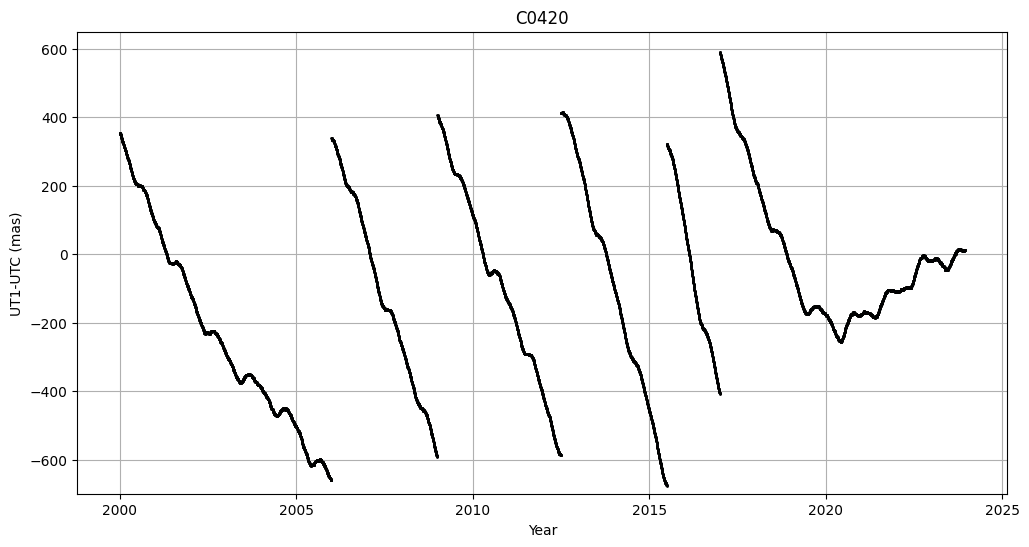

In [33]:
plt.figure(figsize=(12,6))
plt.title('C0420')
plt.errorbar(df_UTC['DATE'], df_UTC['UTC'],yerr=df_UTC['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-700,650)
plt.xlabel('Year')
plt.ylabel('UT1-UTC (mas)')
plt.grid()
plt.show()

In [35]:
df_UTC_sel = df_UTC.iloc[::2]

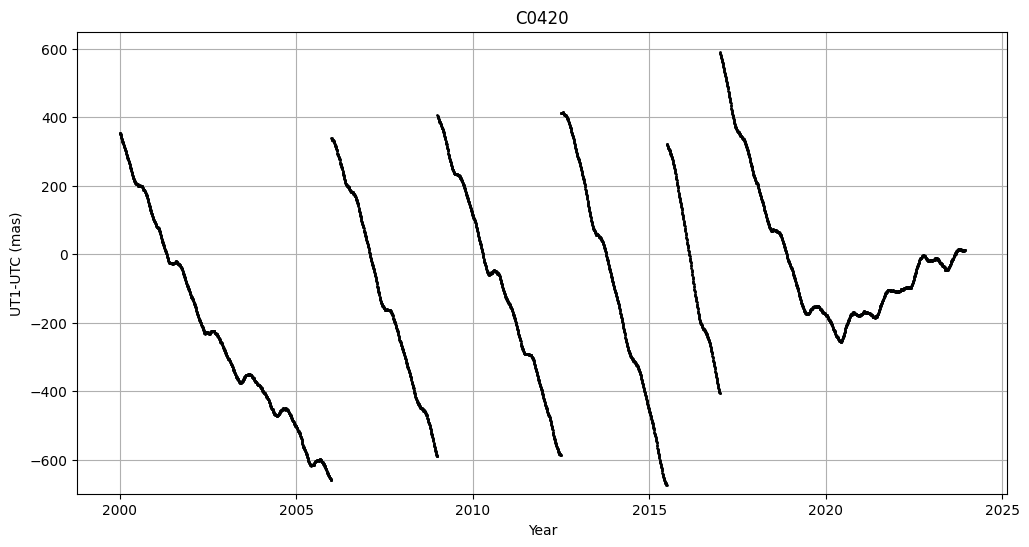

In [36]:
plt.figure(figsize=(12,6))
plt.title('C0420')
plt.errorbar(df_UTC_sel['DATE'], df_UTC_sel['UTC'],yerr=df_UTC_sel['SIGMA'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-700,650)
plt.xlabel('Year')
plt.ylabel('UT1-UTC (mas)')
plt.grid()
plt.show()

In [38]:
tau_UTC, allanstd_UTC = allanself.oadev(df_UTC_sel['UTC'].values,df_UTC_sel['DATE'].values,df_UTC_sel['SIGMA'].values)

In [ ]:
tau_UTC_had, hadstd_UTC = allanself.ohdev(df_UTC_sel['UTC'].values,df_UTC_sel['DATE'].values,df_UTC_sel['SIGMA'].values)

In [ ]:
np.savetxt('allanstd_UTC.txt', allanstd_UTC)
np.savetxt('tau_UTC.txt', tau_UTC)

np.savetxt('hadstd_UTC.txt', hadstd_UTC)
np.savetxt('tau_UTC_had.txt', tau_UTC_had)